**Cell 1: Install Dependencies**

In [11]:
!pip install networkx matplotlib openai python-dotenv


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Cell 2: Imports**

In [3]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

**Cell 3: Sample Data**

In [4]:
DOCUMENTS = [
    "Sachin works at Rolls Royce",
    "Rolls Royce builds aircraft engines",
    "Aircraft engines are used in airplanes",
    "Airplanes carry passengers"
]

** Cell 4: Build Graph**

In [5]:
def build_graph(documents):
    G = nx.Graph()

    for doc in documents:
        words = doc.lower().split()

        # add nodes
        for word in words:
            G.add_node(word)

        # add edges + store sentence
        for i in range(len(words) - 1):
            G.add_edge(words[i], words[i+1], sentence=doc)

    return G


graph = build_graph(DOCUMENTS)
print("Graph built with nodes:", len(graph.nodes()))

Graph built with nodes: 14


**Cell 5: Visualize Graph**

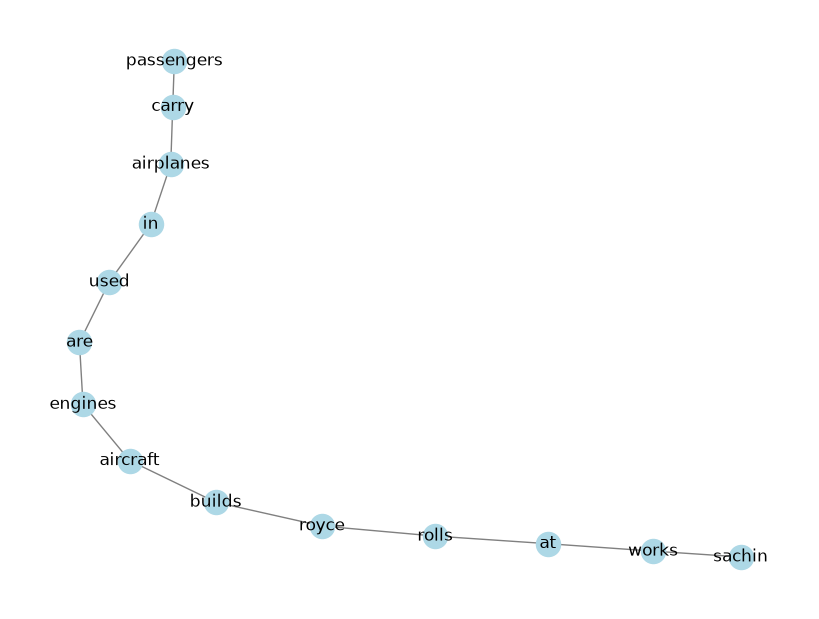

In [6]:
plt.figure(figsize=(8,6))
nx.draw(graph, with_labels=True, node_color="lightblue", edge_color="gray")
plt.show()

**Cell 6: Graph Retrieval**

In [7]:
def retrieve_context(graph, query, max_hops=2):
    query_words = query.lower().split()
    context_sentences = set()

    for word in query_words:
        if word in graph:
            lengths = nx.single_source_shortest_path_length(graph, word, cutoff=max_hops)

            for node in lengths:
                for neighbor in graph.neighbors(node):
                    edge_data = graph.get_edge_data(node, neighbor)

                    if edge_data and "sentence" in edge_data:
                        context_sentences.add(edge_data["sentence"])

    return "\n".join(context_sentences)

**Cell 7: Test Retrieval**

In [8]:
query = "What does Rolls Royce build?"

context = retrieve_context(graph, query)

print("Retrieved Context:\n")
print(context)

Retrieved Context:

Rolls Royce builds aircraft engines
Aircraft engines are used in airplanes
Sachin works at Rolls Royce


**Cell 8: LLM Integration (Azure OpenAI)**

In [9]:
import os
from openai import AzureOpenAI
from dotenv import load_dotenv

load_dotenv()

client = AzureOpenAI(
    api_key=os.getenv("AZURE_OPENAI_API_KEY"),
    azure_endpoint=os.getenv("AZURE_OPENAI_ENDPOINT"),
    api_version="2024-02-15-preview"
)
def ask_llm(context, query):
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": "Answer using only the given context."},
            {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {query}"}
        ]
    )
    
    return response.choices[0].message.content

**Cell 9: Final Answer**

In [10]:
answer = ask_llm(context, query)

print("Final Answer:\n")
print(answer)

Final Answer:

Rolls Royce builds aircraft engines.


**What You Built (Simple)

👉 Text → Graph
👉 Query → Graph traversal
👉 Graph → Context
👉 Context → LLM → Answer**